# Gaussian Mixture Model (GMM) on Customer Credit Card Data
This notebook preprocesses the data, runs GMM model selection via AIC and BIC metrics, trains the final GMM, and saves the pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
import joblib


In [2]:
df = pd.read_csv('CC GENERAL.csv')
X = df.drop(columns=['CUST_ID'])

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_scaled = preprocessor.fit_transform(X)


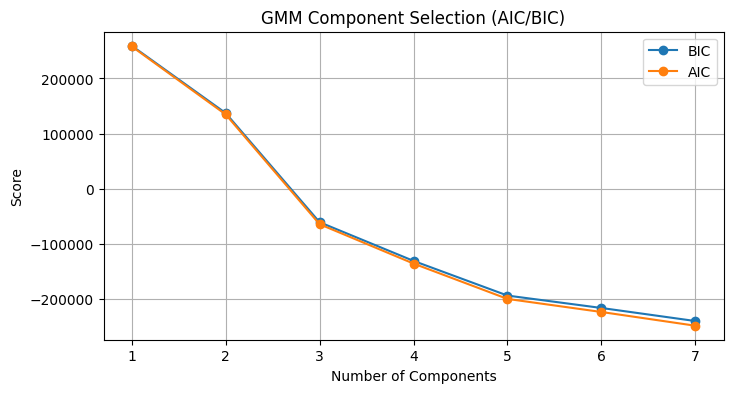

In [3]:
# AIC/BIC analysis for optimal components
n_components = range(1, 8)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled) for n in n_components]

plt.figure(figsize=(8, 4))
plt.plot(n_components, [m.bic(X_scaled) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X_scaled) for m in models], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('GMM Component Selection (AIC/BIC)')
plt.grid(True)
plt.show()


In [4]:
# Fit GMM Pipeline
gmm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('gmm', GaussianMixture(n_components=4, covariance_type='full', random_state=42))
])
gmm_pipeline.fit(X)
joblib.dump(gmm_pipeline, 'gmm_model.pkl')
print('GMM Model Pipeline saved successfully!')


GMM Model Pipeline saved successfully!
